In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [2]:
def load_dict_from_pickle(filename):
    try:
        with open(filename, 'rb') as f:
            data = pickle.load(f)
        return data
    except FileNotFoundError:
        print(f"Файл {filename} не найден.")
        return None
    except Exception as e:
        print(f"Ошибка при загрузке: {e}")
        return None

In [11]:
def plot_comparison(error, attack, metric, ylabel):
    fig, ax = plt.subplots(1, 2, figsize = (18, 9))
    
    styles = {
        'Нью-Йорк (сетчатая)': {'color': '#2ecc71', 'ls': '-', 'lw': 4},
        'Москва (кольцевая)': {'color': '#3498db', 'ls': '--', 'lw': 4},
        'Лондон (хаотичная)': {'color': '#f1c40f', 'ls': '-.', 'lw': 4},
        'Волгоград (линейная)': {'color': '#e74c3c', 'ls': ':', 'lw': 4}
    }   

    fractions = np.linspace(0, 1, 51)

    for city_name, data in error.items():
        values = [np.mean(data[f][metric]) for f in fractions]
        
        style = styles.get(city_name)
        ax[0].plot(fractions, values, label=city_name, **style)
    
    ax[0].set_xlabel('Доля удаленных узлов', fontsize=20)
    ax[0].set_ylabel(ylabel, fontsize=20)
    ax[0].grid(True, which='both', ls='--', alpha=0.5)
    ax[0].tick_params(axis='both', which='major', labelsize=18)
    ax[0].set_xlim(0, 1)
    ax[0].set_ylim(0, None)
    
    for city_name, data in attack.items():
        values = [np.mean(data[f][metric]) for f in fractions]
        
        style = styles.get(city_name)
        ax[1].plot(fractions, values, label=city_name, **style)
    
    ax[1].set_xlabel('Доля удаленных узлов', fontsize=20)
    ax[1].set_ylabel(ylabel, fontsize=20)
    ax[1].grid(True, which='both', ls='--', alpha=0.5)
    ax[1].tick_params(axis='both', which='major', labelsize=18)
    ax[1].set_xlim(0, 1)
    ax[1].set_ylim(0, None)
    
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, 
               loc='lower center', 
               bbox_to_anchor=(0.5, -0.1),
               ncol=4,                      
               fontsize=20, 
               frameon=True)

    plt.tight_layout()
    return fig

## Загрузка

In [12]:
Moscow_error = load_dict_from_pickle("./Stats/Moscow_error.pkl")
Moscow_attack = load_dict_from_pickle("./Stats/Moscow_attack.pkl")

New_York_error = load_dict_from_pickle("./Stats/New_York_error.pkl")
New_York_attack = load_dict_from_pickle("./Stats/New_York_attack.pkl")

Volgograd_error = load_dict_from_pickle("./Stats/Volgograd_error.pkl")
Volgograd_attack = load_dict_from_pickle("./Stats/Volgograd_attack.pkl")

London_error = load_dict_from_pickle("./Stats/London_error.pkl")
London_attack = load_dict_from_pickle("./Stats/London_attack.pkl")

## Визуализация

In [15]:
error = {
    'Нью-Йорк (сетчатая)': New_York_error,
    'Москва (кольцевая)': Moscow_error,
    'Лондон (хаотичная)': London_error,
    'Волгоград (линейная)': Volgograd_error
}

attack = {
    'Нью-Йорк (сетчатая)': New_York_attack,
    'Москва (кольцевая)': Moscow_attack,
    'Лондон (хаотичная)': London_attack,
    'Волгоград (линейная)': Volgograd_attack
}

### GCC (Giant Connected Component)

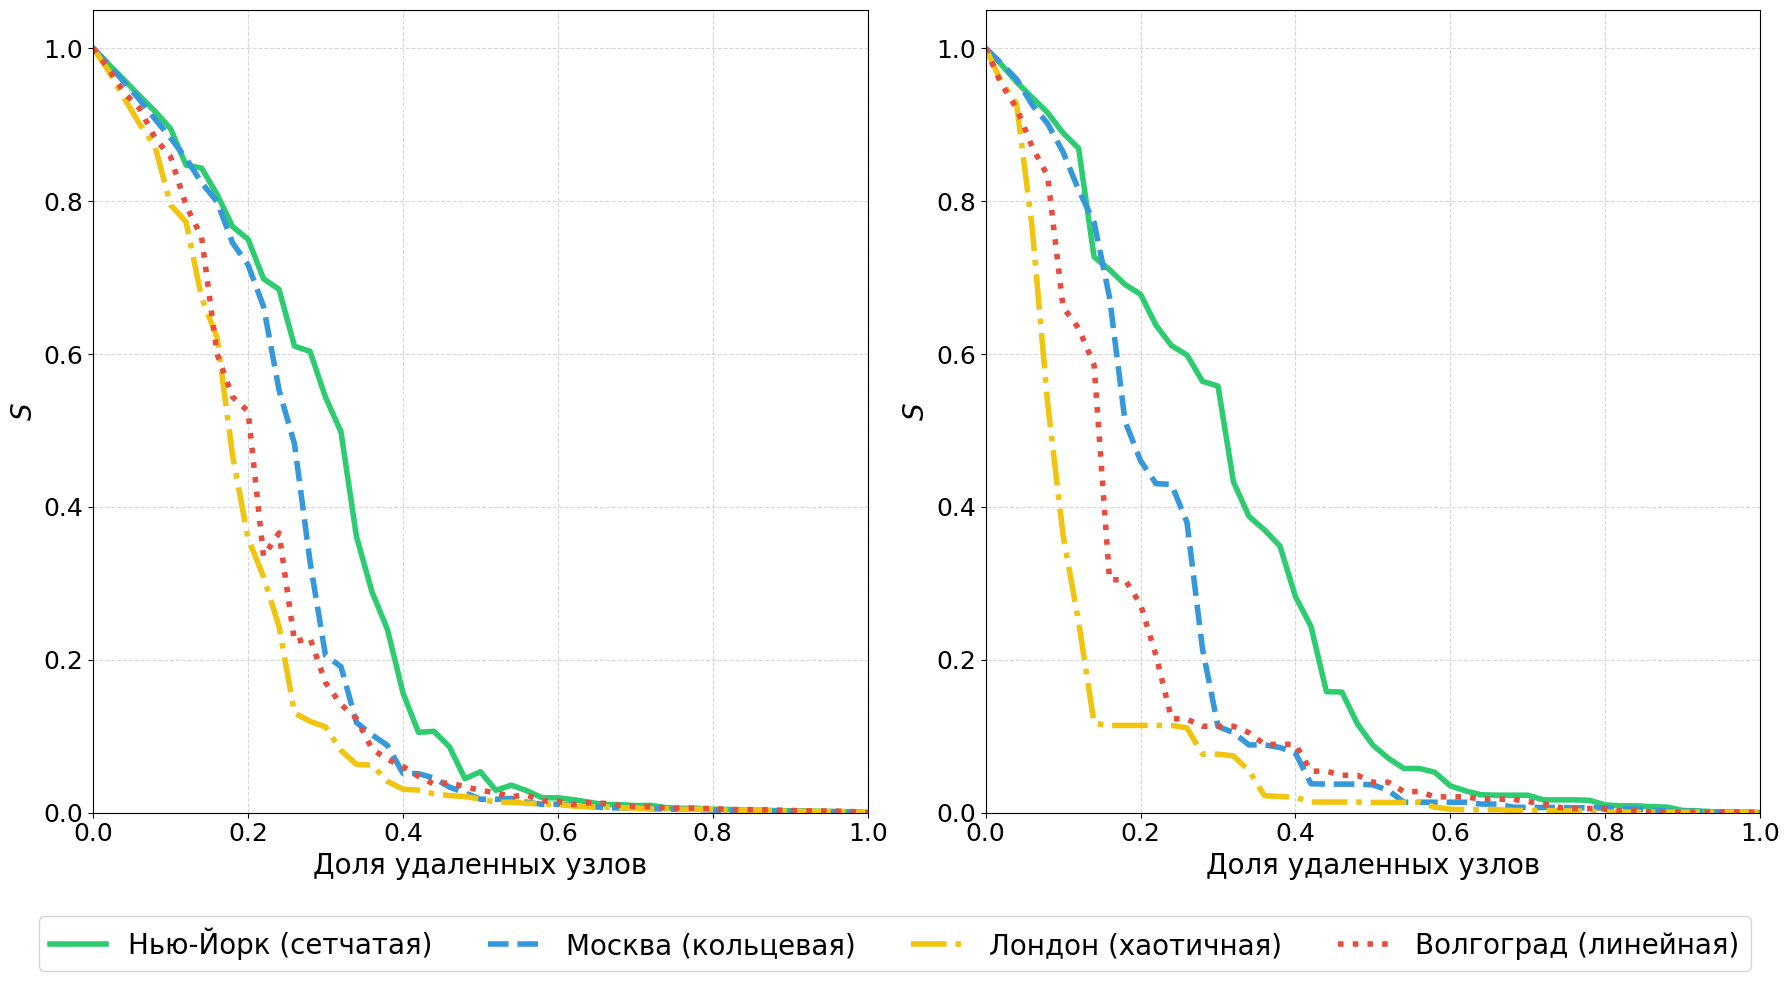

In [26]:
fig = plot_comparison(error, attack, "gcc", "$S$")

In [27]:
fig.savefig(
    './Graphics/gcc.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)

### Average Size of Isolated Clusters

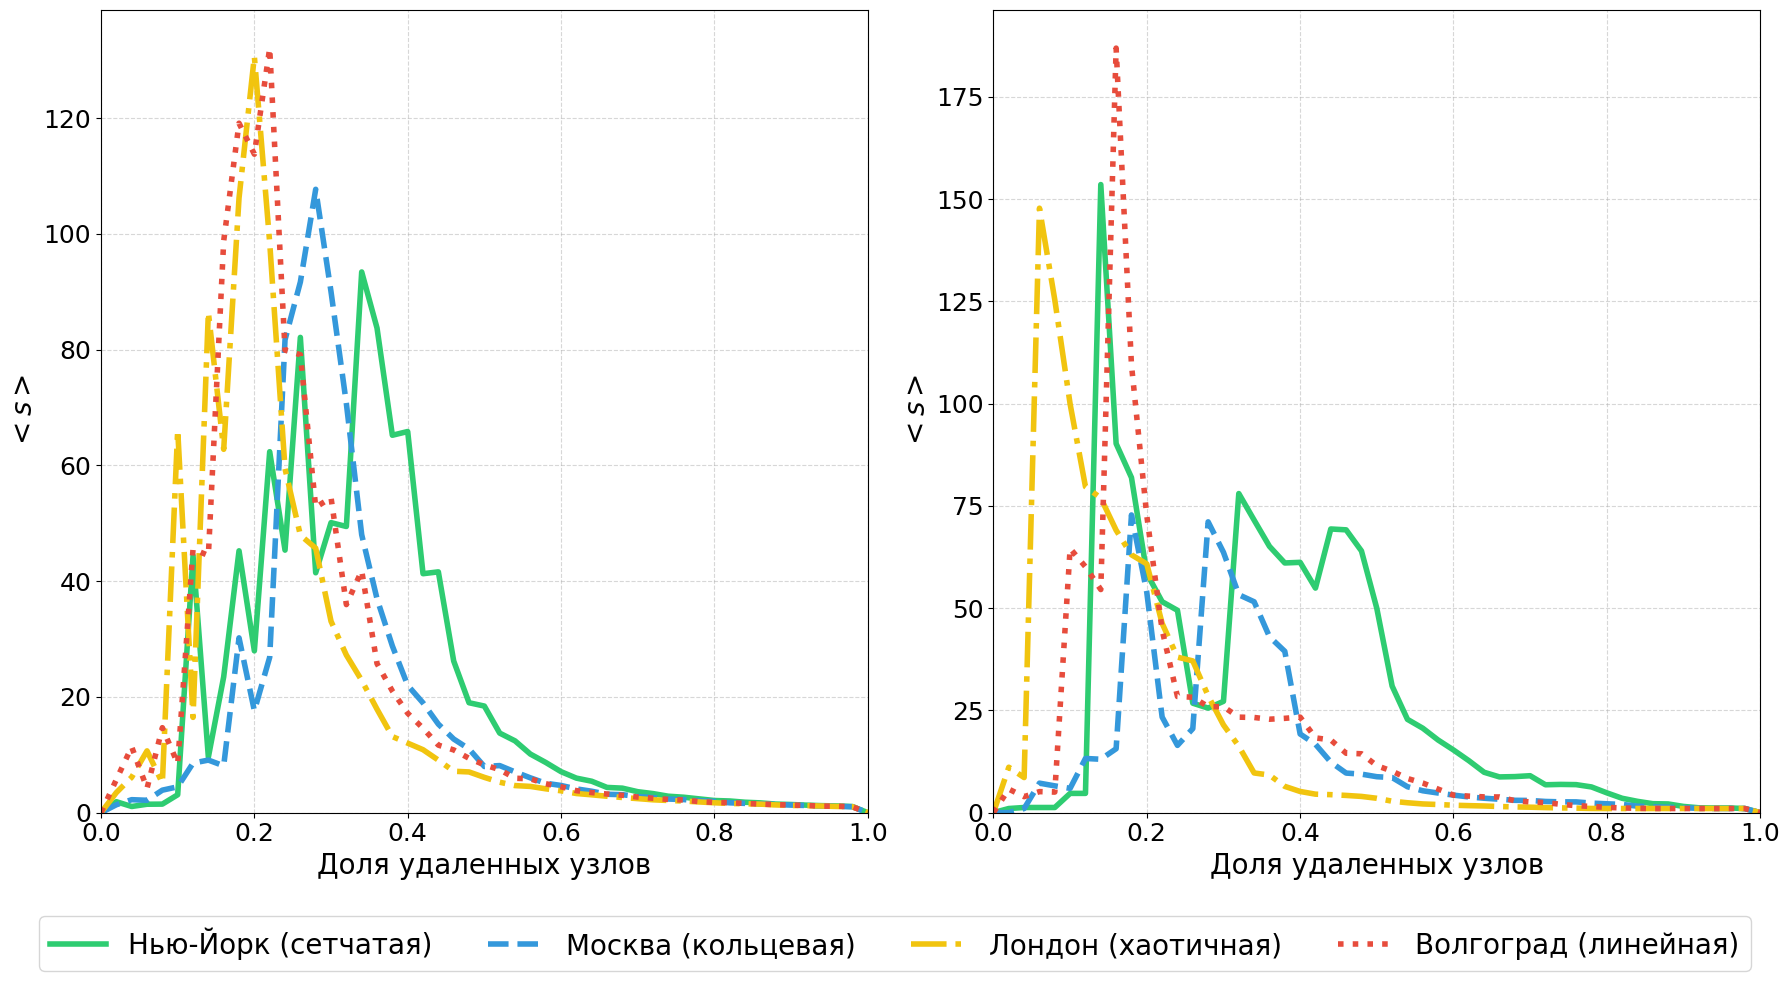

In [32]:
fig = plot_comparison(error, attack, "avg_s", "$<s>$")

In [33]:
fig.savefig(
    './Graphics/avg_s.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)

### Topological Diameter

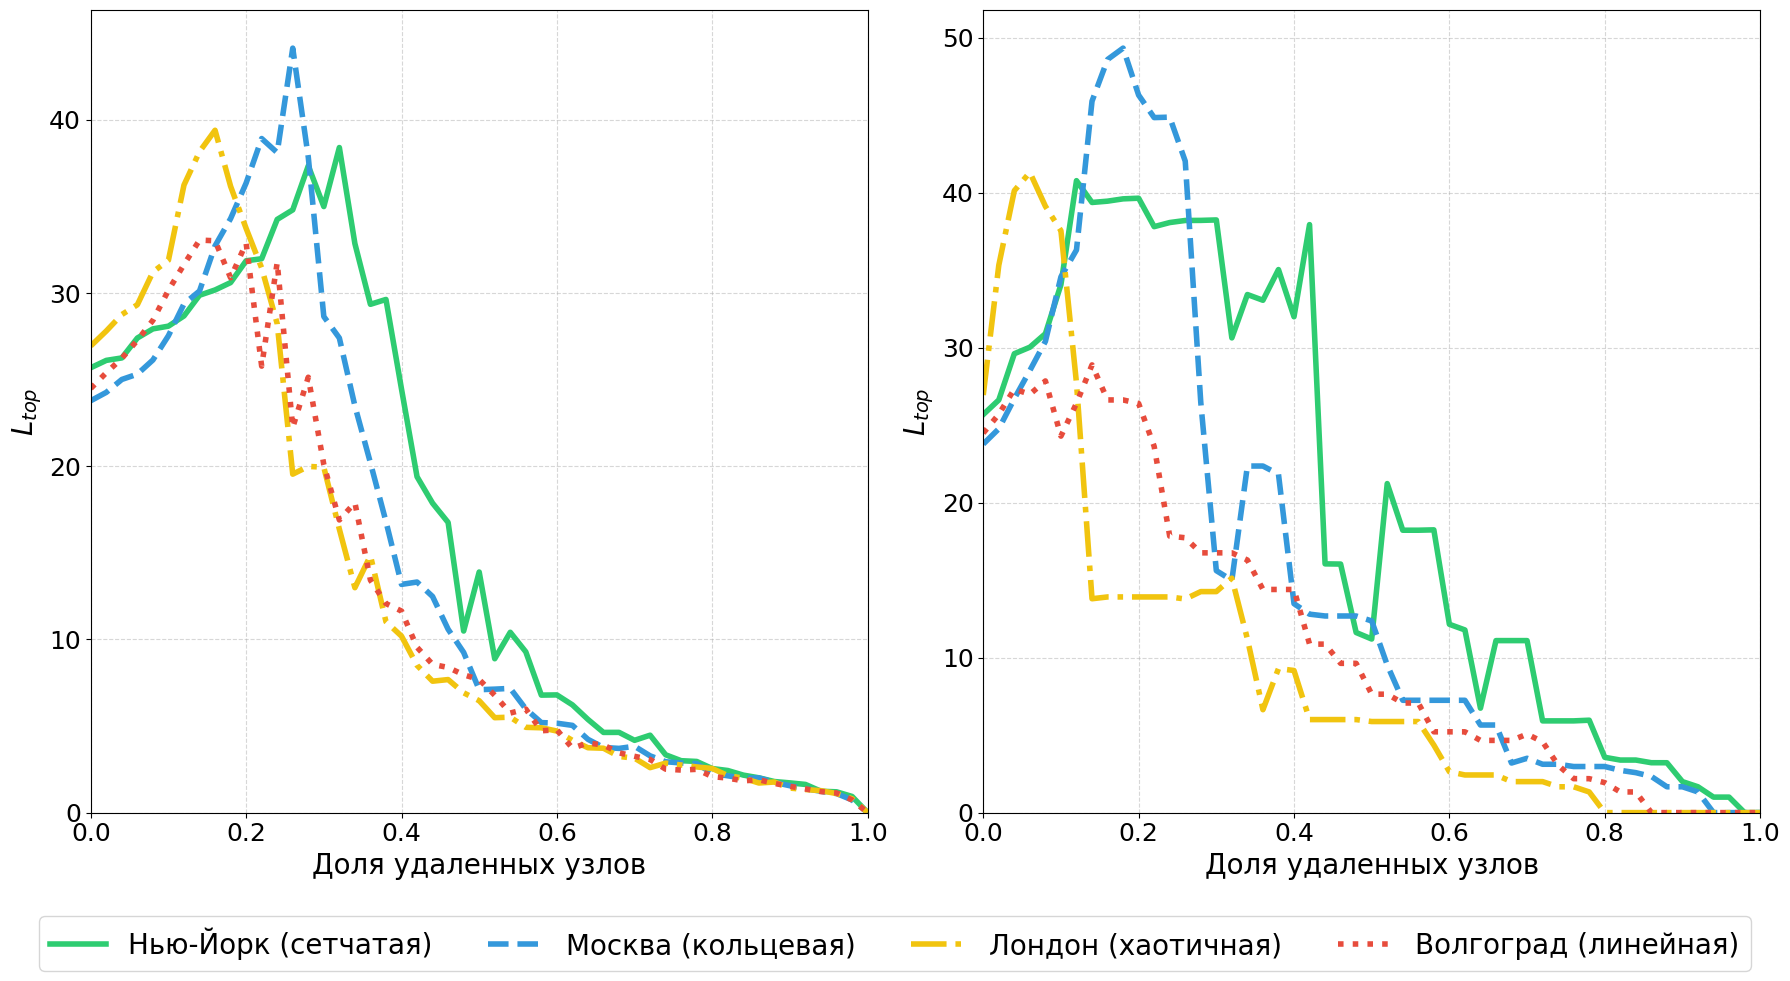

In [34]:
fig = plot_comparison(error, attack, "top_d", "$L_{top}$")

In [35]:
fig.savefig(
    './Graphics/top_d.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)

### Length Diameter

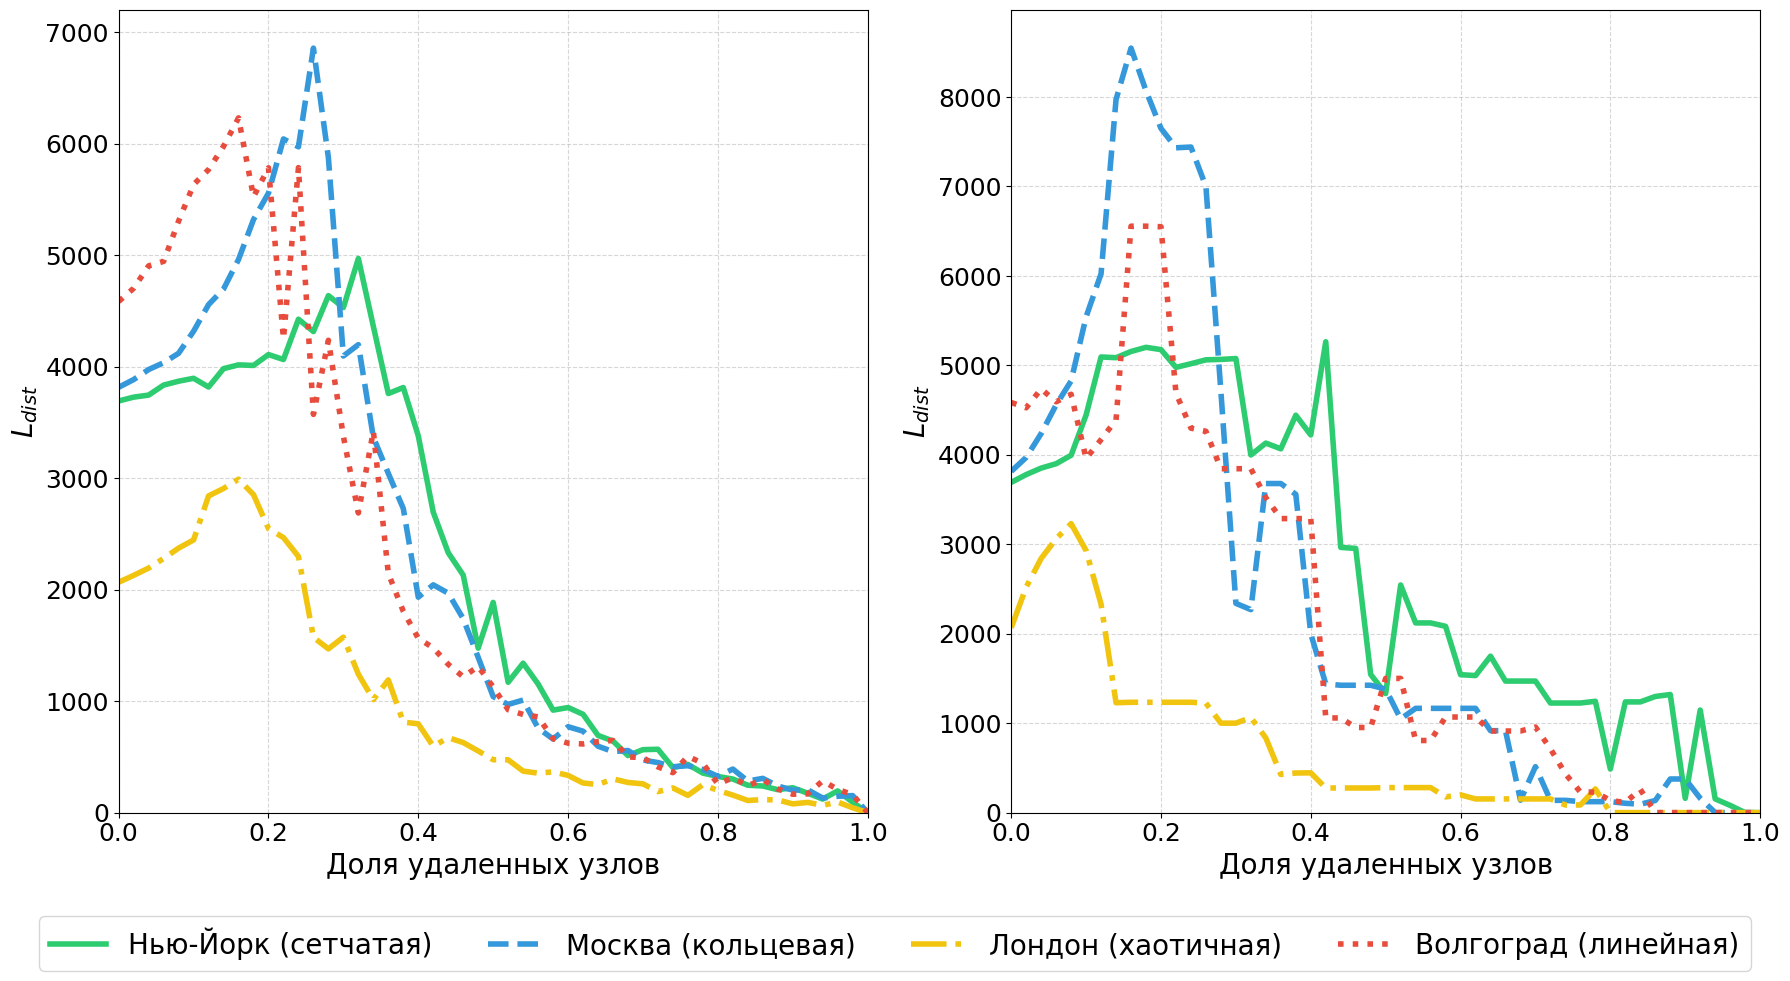

In [36]:
fig = plot_comparison(error, attack, "len_d", "$L_{dist}$")

In [37]:
fig.savefig(
    './Graphics/len_d.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)

### Global Efficiency

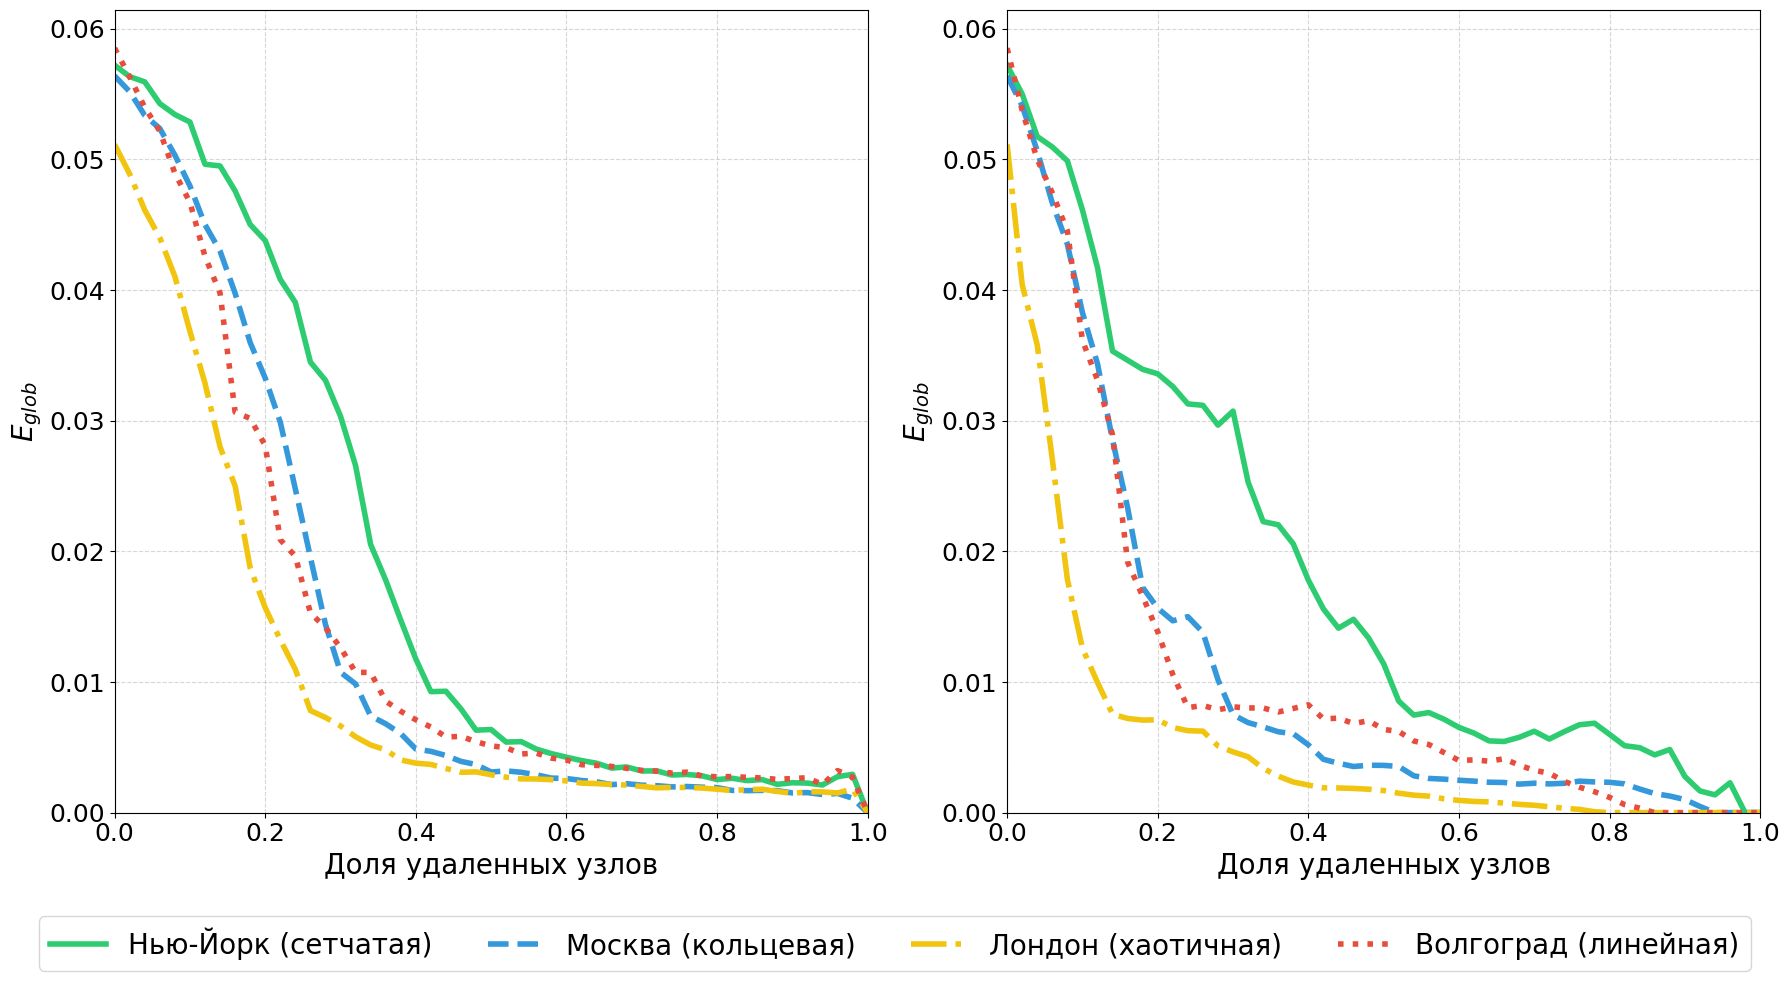

In [38]:
fig = plot_comparison(error, attack, "ge", "$E_{glob}$")

In [39]:
fig.savefig(
    './Graphics/ge.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)

### Local Clustering Coefficient

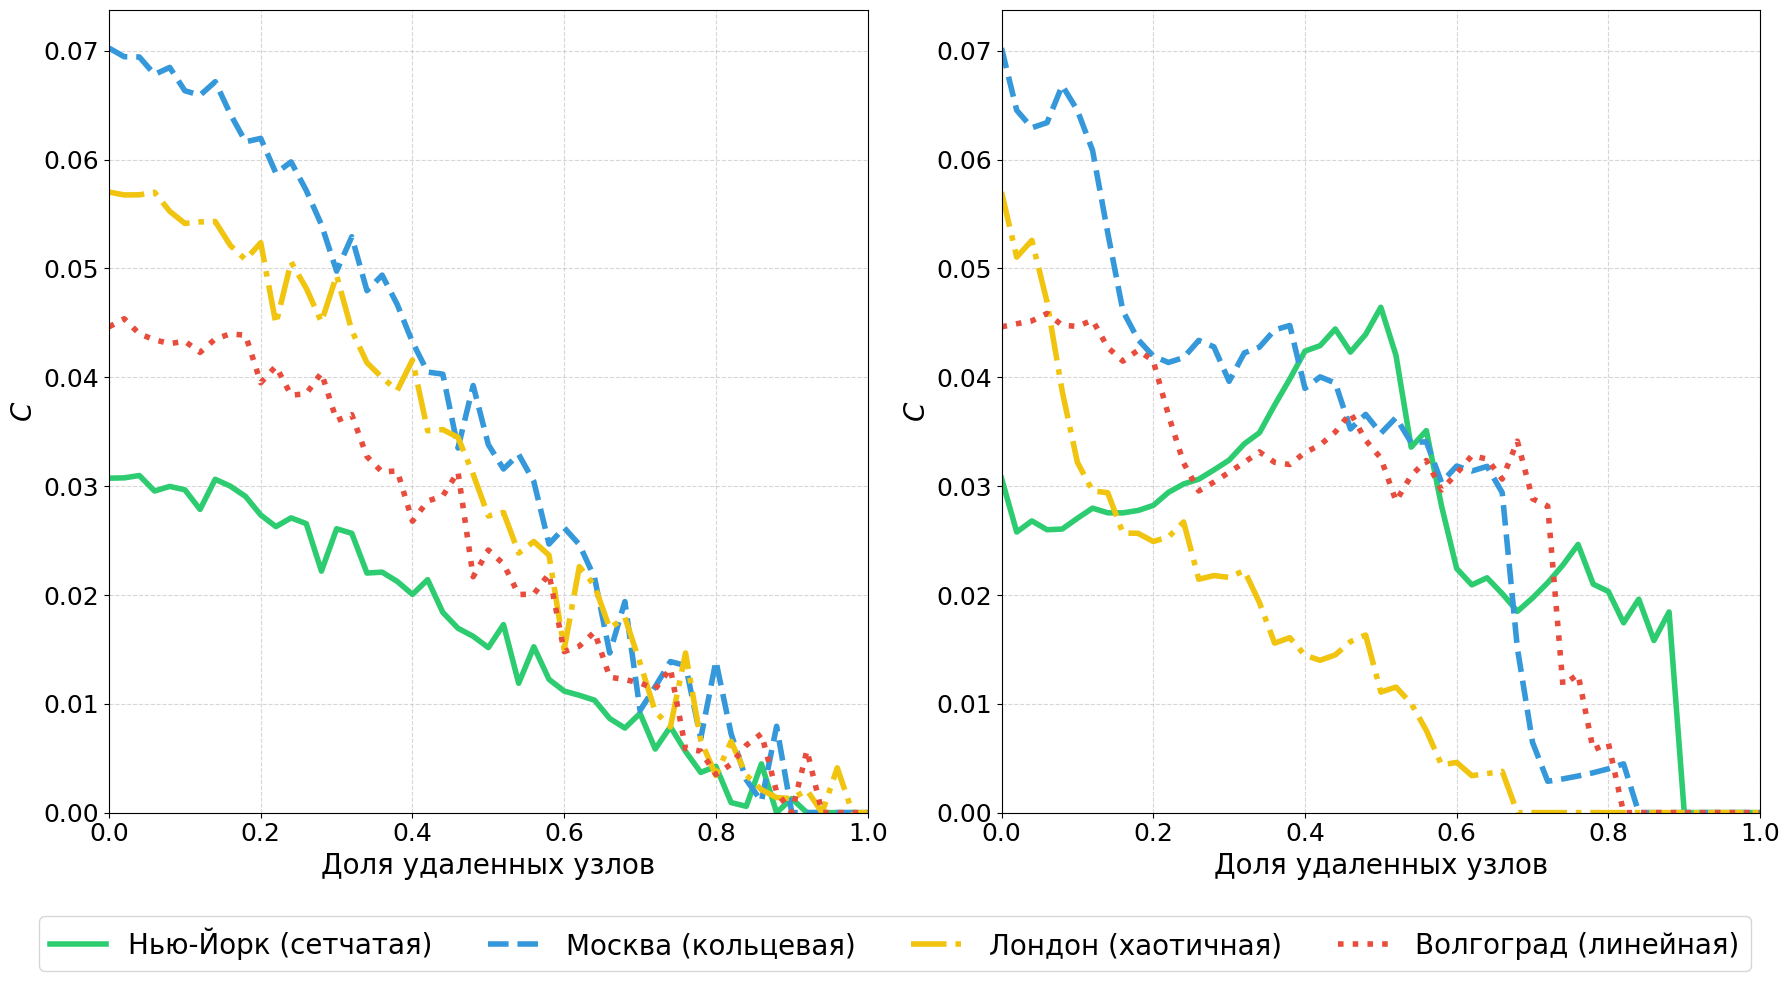

In [40]:
fig = plot_comparison(error, attack, "lcc", "$C$")

In [41]:
fig.savefig(
    './Graphics/lcc.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)